In [5]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import os

In [6]:
os.chdir("/Users/kaiping/Desktop/olist_project/data") 
os.getcwd()

'/Users/kaiping/Desktop/olist_project/data'

### 1. 資料欄位過濾  
區分三大塊影響顧客二購意願模塊    

A. 交易強度  
first_purchase_gmv  
first_item_cnt  
first_category_cnt  
seller_cnt  
first_freight_ratio  

B. 體驗品質  
has_review  
first_review_score  
delivery_days  
delivery_delay_days  
late_flag  

C. 顧客 / 場景資訊  
customer_state  
purchase_month  
same_ts_multi_order_flag   

In [7]:
df_translation = pd.read_csv("raw/product_category_name_translation.csv")
df_sellers     = pd.read_csv("raw/olist_sellers_dataset.csv")
df_products    = pd.read_csv("raw/olist_products_dataset.csv")
df_orders      = pd.read_csv("raw/olist_orders_dataset.csv")
df_order_reviews  = pd.read_csv("raw/olist_order_reviews_dataset.csv")
df_order_payments = pd.read_csv("raw/olist_order_payments_dataset.csv")
df_order_items    = pd.read_csv("raw/olist_order_items_dataset.csv")
df_geolocation    = pd.read_csv("raw/olist_geolocation_dataset.csv")
df_customers      = pd.read_csv("raw/olist_customers_dataset.csv")


只使用 delivered 訂單
用 同一個 customer_unique_id + 同一個 order_purchase_timestamp 視為同一個 purchase event
排除資料尾端 90 天，避免 right censoring

In [8]:
analysis_end = pd.Timestamp("2018-05-31 23:59:59")

# =========================
# 1. 基礎清理：時間欄位轉型
# =========================
time_cols_orders = [
    "order_purchase_timestamp",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]
for col in time_cols_orders:
    df_orders[col] = pd.to_datetime(df_orders[col], errors="coerce")

# reviews 只需要 score
df_order_reviews["review_score"] = pd.to_numeric(
    df_order_reviews["review_score"], errors="coerce"
)

# 數值欄位
for col in ["price", "freight_value"]:
    df_order_items[col] = pd.to_numeric(df_order_items[col], errors="coerce")


# =========================
# 2. delivered 訂單口徑
# =========================
orders_base = df_orders.loc[
    df_orders["order_status"] == "delivered",
    [
        "order_id",
        "customer_id",
        "order_purchase_timestamp",
        "order_delivered_customer_date",
        "order_estimated_delivery_date"
    ]
].copy()

# 合併 customer_unique_id / customer_state
orders_base = orders_base.merge(
    df_customers[["customer_id", "customer_unique_id", "customer_state"]],
    on="customer_id",
    how="left"
)

# 移除關鍵空值
orders_base = orders_base.dropna(
    subset=["customer_unique_id", "order_purchase_timestamp"]
).copy()


# =========================
# 3. 設定 analysis_end
#    排除最後 90 天首購樣本，避免 right censoring
# =========================
data_end = orders_base["order_purchase_timestamp"].max()
analysis_end = data_end - pd.Timedelta(days=90)

print("data_end      :", data_end)
print("analysis_end  :", analysis_end)


# =========================
# 4. order_items 聚合到訂單層級
# =========================
# 補商品類別
items = df_order_items.merge(
    df_products[["product_id", "product_category_name"]],
    on="product_id",
    how="left"
)

# order-level 指標
order_items_agg = (
    items.groupby("order_id")
    .agg(
        item_cnt=("product_id", "size"),
        category_cnt=("product_category_name", "nunique"),
        seller_cnt=("seller_id", "nunique"),
        item_price_sum=("price", "sum"),
        freight_sum=("freight_value", "sum")
    )
    .reset_index()
)

# 這裡定義 gmv = price + freight
order_items_agg["order_gmv"] = (
    order_items_agg["item_price_sum"] + order_items_agg["freight_sum"]
)


# =========================
# 5. review 聚合到訂單層級
# =========================
order_review_agg = (
    df_order_reviews.groupby("order_id")
    .agg(
        review_score_mean=("review_score", "mean"),
        has_review=("review_score", lambda x: int(x.notna().any()))
    )
    .reset_index()
)


# =========================
# 6. 建立訂單層級 base
# =========================
order_level = (
    orders_base
    .merge(order_items_agg, on="order_id", how="left")
    .merge(order_review_agg, on="order_id", how="left")
)

# 缺值補 0 / NaN 視需求
for col in ["item_cnt", "category_cnt", "seller_cnt", "item_price_sum", "freight_sum", "order_gmv"]:
    order_level[col] = order_level[col].fillna(0)

order_level["has_review"] = order_level["has_review"].fillna(0).astype(int)

# 配送體驗欄位
order_level["delivery_days"] = (
    order_level["order_delivered_customer_date"] - order_level["order_purchase_timestamp"]
).dt.total_seconds() / 86400

order_level["delivery_delay_days"] = (
    order_level["order_delivered_customer_date"] - order_level["order_estimated_delivery_date"]
).dt.total_seconds() / 86400

# 早到不算 delay，clip 到 >= 0
order_level["delivery_delay_days"] = order_level["delivery_delay_days"].clip(lower=0)

order_level["late_flag"] = (
    order_level["delivery_delay_days"].fillna(0) > 0
).astype(int)


# =========================
# 7. 建立 purchase event
#    同 customer_unique_id + 同 timestamp 視為同一個 purchase event
# =========================
purchase_event = (
    order_level.groupby(["customer_unique_id", "order_purchase_timestamp"])
    .agg(
        event_order_cnt=("order_id", "nunique"),
        customer_state=("customer_state", "first"),

        # A. 交易強度
        first_purchase_gmv=("order_gmv", "sum"),
        first_item_cnt=("item_cnt", "sum"),
        first_category_cnt=("category_cnt", "sum"),  # 先暫存，後面會改成真正 event-level category unique
        seller_cnt=("seller_cnt", "sum"),            # 先暫存，後面會改成真正 event-level seller unique
        freight_sum=("freight_sum", "sum"),

        # B. 體驗品質
        has_review=("has_review", "max"),
        first_review_score=("review_score_mean", "mean"),
        delivery_days=("delivery_days", "mean"),
        delivery_delay_days=("delivery_delay_days", "mean"),
        late_flag=("late_flag", "max")
    )
    .reset_index()
)

# purchase_month
purchase_event["purchase_month"] = (
    purchase_event["order_purchase_timestamp"]
    .dt.to_period("M")
    .dt.to_timestamp()
)

# 同 timestamp 是否多筆訂單
purchase_event["same_ts_multi_order_flag"] = (
    purchase_event["event_order_cnt"] > 1
).astype(int)

# freight ratio = freight / gmv
purchase_event["first_freight_ratio"] = np.where(
    purchase_event["first_purchase_gmv"] > 0,
    purchase_event["freight_sum"] / purchase_event["first_purchase_gmv"],
    np.nan
)


# =========================
# 8. 修正 event-level 的真正 category_cnt / seller_cnt
#    避免直接把 order-level nunique 加總而重複計數
# =========================
event_item_map = (
    order_level[
        ["customer_unique_id", "order_purchase_timestamp", "order_id"]
    ]
    .merge(
        items[["order_id", "product_category_name", "seller_id"]],
        on="order_id",
        how="left"
    )
)

event_unique_agg = (
    event_item_map.groupby(["customer_unique_id", "order_purchase_timestamp"])
    .agg(
        first_category_cnt=("product_category_name", "nunique"),
        seller_cnt=("seller_id", "nunique")
    )
    .reset_index()
)

purchase_event = purchase_event.drop(columns=["first_category_cnt", "seller_cnt"]).merge(
    event_unique_agg,
    on=["customer_unique_id", "order_purchase_timestamp"],
    how="left"
)

purchase_event["first_category_cnt"] = purchase_event["first_category_cnt"].fillna(0)
purchase_event["seller_cnt"] = purchase_event["seller_cnt"].fillna(0)


# =========================
# 9. 找每位顧客的第一個 / 第二個 purchase event
# =========================
purchase_event = purchase_event.sort_values(
    ["customer_unique_id", "order_purchase_timestamp"]
).reset_index(drop=True)

purchase_event["purchase_event_rank"] = (
    purchase_event.groupby("customer_unique_id").cumcount() + 1
)

first_event = purchase_event.loc[
    purchase_event["purchase_event_rank"] == 1
].copy()

second_event = purchase_event.loc[
    purchase_event["purchase_event_rank"] == 2,
    ["customer_unique_id", "order_purchase_timestamp"]
].copy()
second_event = second_event.rename(
    columns={"order_purchase_timestamp": "second_purchase_ts"}
)

abt = first_event.merge(
    second_event,
    on="customer_unique_id",
    how="left"
)

abt = abt.rename(
    columns={"order_purchase_timestamp": "first_purchase_ts"}
)


# =========================
# 10. 排除 right censoring
#     只保留 first_purchase_ts <= analysis_end 的首購客
# =========================
abt = abt.loc[
    abt["first_purchase_ts"] <= analysis_end
].copy()


# =========================
# 11. 建立二購 label
#     首購後 90 天內是否發生第二個 purchase event
# =========================
abt["days_to_2nd_purchase"] = (
    abt["second_purchase_ts"] - abt["first_purchase_ts"]
).dt.total_seconds() / 86400

abt["purchase_2nd_within_90d"] = (
    abt["days_to_2nd_purchase"].between(0, 90, inclusive="both")
).fillna(False).astype(int)


# =========================
# 12. 保留你要的欄位
# =========================
abt_2nd_purchase = abt[
    [
        "customer_unique_id",

        # 時間 / 場景
        "first_purchase_ts",
        "purchase_month",
        "customer_state",
        "same_ts_multi_order_flag",

        # A. 交易強度
        "first_purchase_gmv",
        "first_item_cnt",
        "first_category_cnt",
        "seller_cnt",
        "first_freight_ratio",

        # B. 體驗品質
        "has_review",
        "first_review_score",
        "delivery_days",
        "delivery_delay_days",
        "late_flag",

        # label / 輔助欄位
        "second_purchase_ts",
        "days_to_2nd_purchase",
        "purchase_2nd_within_90d"
    ]
].copy()


# =========================
# 13. 基本檢查
# =========================
print("\nABT shape:", abt_2nd_purchase.shape)
print("\n二購率（90天內）:")
print(abt_2nd_purchase["purchase_2nd_within_90d"].mean())

print("\n欄位缺值率:")
print(abt_2nd_purchase.isna().mean().sort_values(ascending=False).head(15))

print("\n前幾筆:")
print(abt_2nd_purchase.head())




data_end      : 2018-08-29 15:00:00
analysis_end  : 2018-05-31 15:00:00

ABT shape: (75320, 18)

二購率（90天內）:
0.014763674986723313

欄位缺值率:
days_to_2nd_purchase        0.973181
second_purchase_ts          0.973181
first_review_score          0.007063
delivery_delay_days         0.000027
delivery_days               0.000027
customer_unique_id          0.000000
first_purchase_ts           0.000000
late_flag                   0.000000
has_review                  0.000000
first_freight_ratio         0.000000
seller_cnt                  0.000000
first_category_cnt          0.000000
first_item_cnt              0.000000
first_purchase_gmv          0.000000
same_ts_multi_order_flag    0.000000
dtype: float64

前幾筆:
                 customer_unique_id   first_purchase_ts purchase_month  \
0  0000366f3b9a7992bf8c76cfdf3221e2 2018-05-10 10:56:00     2018-05-01   
1  0000b849f77a49e4a4ce2b2a4ca5be3f 2018-05-07 11:11:00     2018-05-01   
2  0000f46a3911fa3c0805444483337064 2017-03-10 21:05:00     2017-

In [9]:
abt_2nd_purchase = abt_2nd_purchase.rename(
    columns={
        "first_review_score": "first_event_review_score_mean"
    }
)

In [10]:
abt_2nd_purchase.isna().sum()

customer_unique_id                   0
first_purchase_ts                    0
purchase_month                       0
customer_state                       0
same_ts_multi_order_flag             0
first_purchase_gmv                   0
first_item_cnt                       0
first_category_cnt                   0
seller_cnt                           0
first_freight_ratio                  0
has_review                           0
first_event_review_score_mean      532
delivery_days                        2
delivery_delay_days                  2
late_flag                            0
second_purchase_ts               73300
days_to_2nd_purchase             73300
purchase_2nd_within_90d              0
dtype: int64

In [11]:
abt_2nd_purchase.columns

Index(['customer_unique_id', 'first_purchase_ts', 'purchase_month',
       'customer_state', 'same_ts_multi_order_flag', 'first_purchase_gmv',
       'first_item_cnt', 'first_category_cnt', 'seller_cnt',
       'first_freight_ratio', 'has_review', 'first_event_review_score_mean',
       'delivery_days', 'delivery_delay_days', 'late_flag',
       'second_purchase_ts', 'days_to_2nd_purchase',
       'purchase_2nd_within_90d'],
      dtype='object')

分析表缺失均為正常缺失，大多數顧客都只有買一次

### 1. overview分析(數值欄位):分析哪些變量會影響回購意願

In [12]:
# label 分佈
label_dist = (
    abt_2nd_purchase["purchase_2nd_within_90d"]
    .value_counts(dropna=False)
    .sort_index()
    .rename_axis("label")
    .reset_index(name="count")
)

label_dist["rate"] = label_dist["count"] / label_dist["count"].sum()
print(label_dist)

   label  count      rate
0      0  74208  0.985236
1      1   1112  0.014764


In [13]:
num_cols = [
    "first_purchase_gmv",
    "first_item_cnt",
    "first_category_cnt",
    "seller_cnt",
    "first_freight_ratio",
    "first_event_review_score_mean",
    "delivery_days",
    "delivery_delay_days"
]

num_summary = (
    abt_2nd_purchase
    .groupby("purchase_2nd_within_90d")[num_cols]
    .agg(["count", "mean", "median", "std"])
)

print(num_summary)

                        first_purchase_gmv                                   \
                                     count        mean   median         std   
purchase_2nd_within_90d                                                       
0                                    74208  160.852733  105.610  219.492500   
1                                     1112  154.502014  104.675  175.956816   

                        first_item_cnt                             \
                                 count      mean median       std   
purchase_2nd_within_90d                                             
0                                74208  1.150024    1.0  0.550822   
1                                 1112  1.271583    1.0  0.870551   

                        first_category_cnt            ...  \
                                     count      mean  ...   
purchase_2nd_within_90d                               ...   
0                                    74208  0.993586  ...   
1             

In [14]:
for col in num_cols:
    print(f"\n{'='*60}")
    print(f"{col}")
    print(f"{'='*60}")

    print(
        abt_2nd_purchase
        .groupby("purchase_2nd_within_90d")[col]
        .describe()
    )


first_purchase_gmv
                           count        mean         std    min    25%  \
purchase_2nd_within_90d                                                  
0                        74208.0  160.852733  219.492500  10.07  62.18   
1                         1112.0  154.502014  175.956816  11.62  59.31   

                             50%       75%       max  
purchase_2nd_within_90d                               
0                        105.610  177.3900  13664.08  
1                        104.675  182.3275   1988.53  

first_item_cnt
                           count      mean       std  min  25%  50%  75%   max
purchase_2nd_within_90d                                                       
0                        74208.0  1.150024  0.550822  1.0  1.0  1.0  1.0  21.0
1                         1112.0  1.271583  0.870551  1.0  1.0  1.0  1.0  15.0

first_category_cnt
                           count      mean       std  min  25%  50%  75%  max
purchase_2nd_within_90d          

只要首購 event 有商品，category_cnt 應該至少是 1

所以 0 通常代表：

該 purchase event 的商品 category 沒被成功識別 / 全部為 missing

針對首購顧客之數值型特徵進行 90 天內二購與否的分組比較後發現，多數變數在兩組間之平均數、中位數與分布差異有限  
，整體呈現高度重疊。  
特別是 first_purchase_gmv、first_category_cnt、first_freight_ratio 等變數，  
在二購與非二購組間幾乎未觀察到明顯分離；first_item_cnt、delivery_days、delivery_delay_days  
與 first_event_review_score_mean 雖存在方向性差異，  
但幅度整體偏小，顯示單一特徵對 90 天內二購行為之解釋力有限。

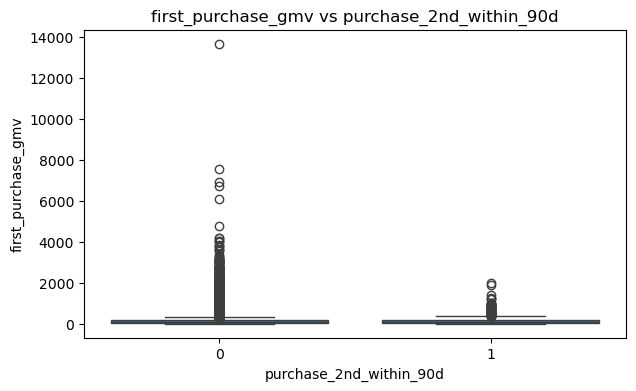

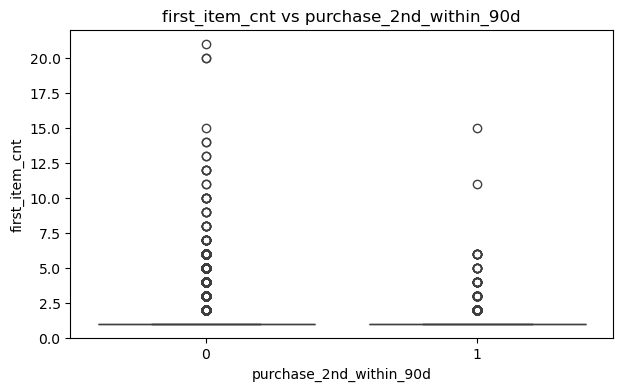

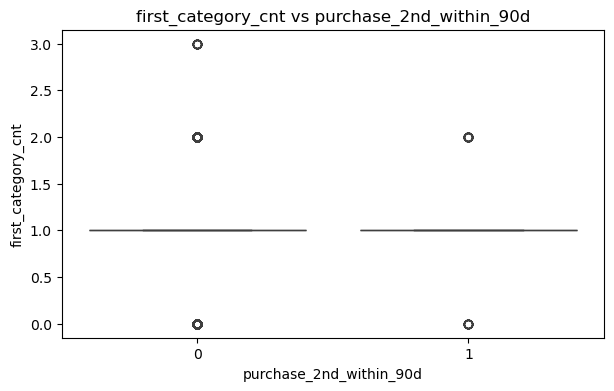

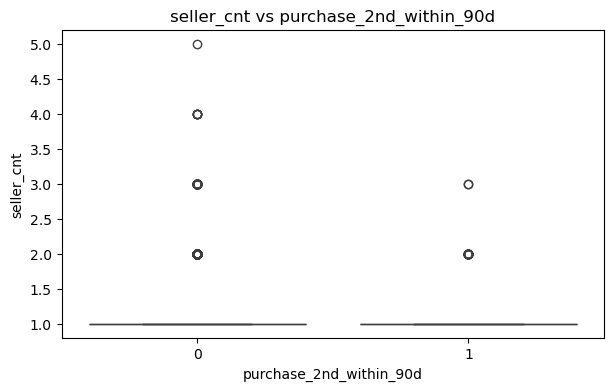

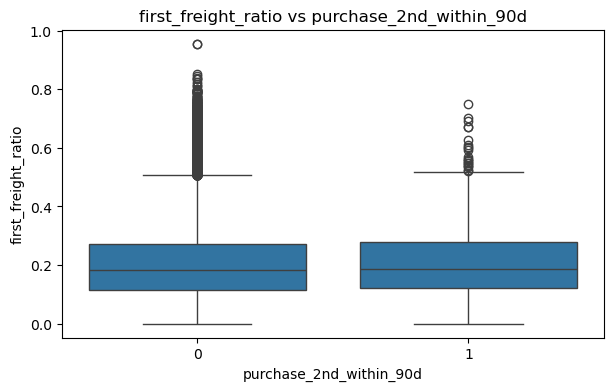

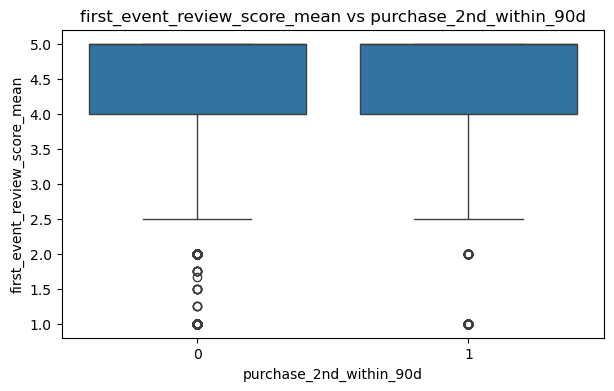

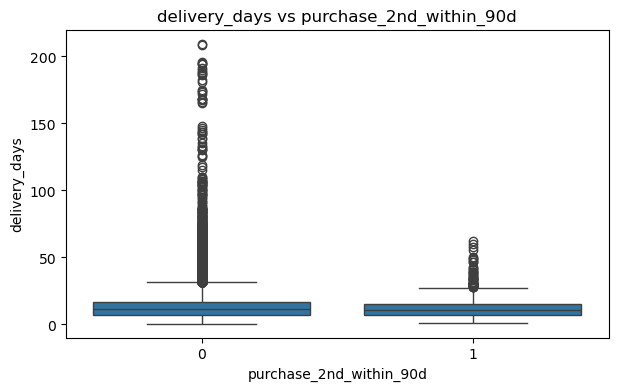

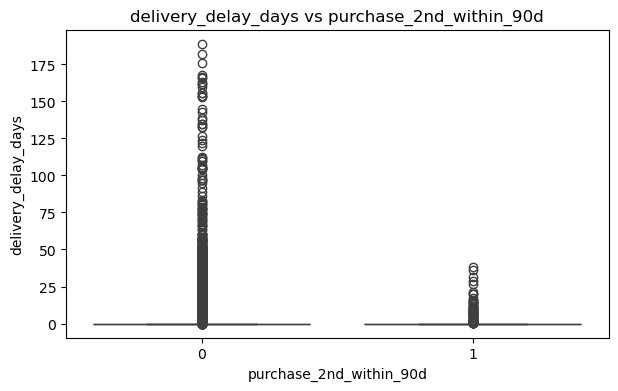

In [15]:
num_cols = [
    "first_purchase_gmv",
    "first_item_cnt",
    "first_category_cnt",
    "seller_cnt",
    "first_freight_ratio",
    "first_event_review_score_mean",
    "delivery_days",
    "delivery_delay_days"
]

for col in num_cols:
    plt.figure(figsize=(7, 4))
    sns.boxplot(
        data=abt_2nd_purchase,
        x="purchase_2nd_within_90d",
        y=col
    )
    plt.title(f"{col} vs purchase_2nd_within_90d")
    plt.show()

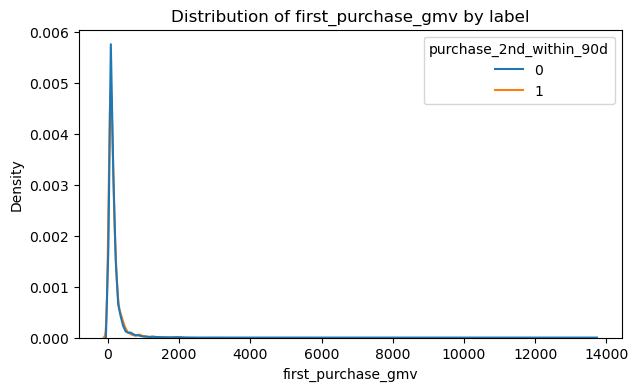

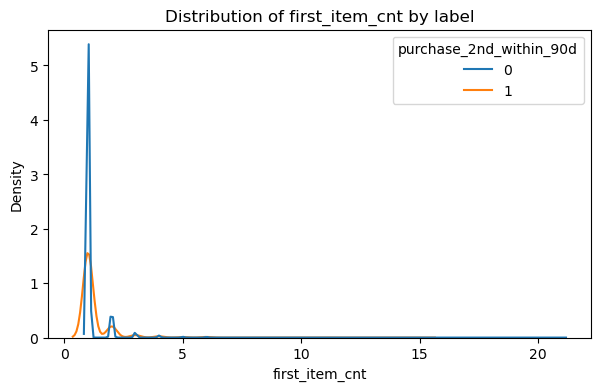

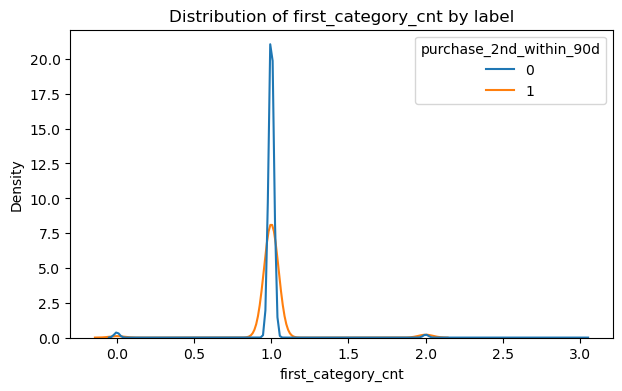

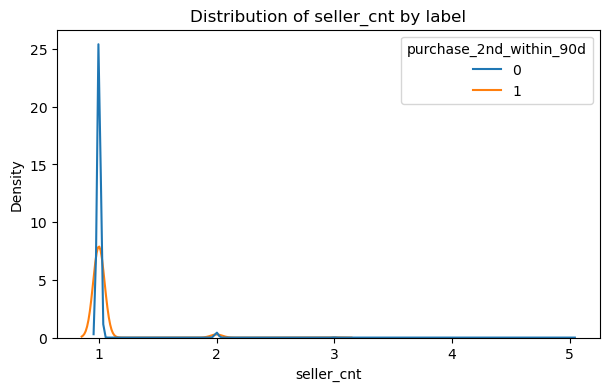

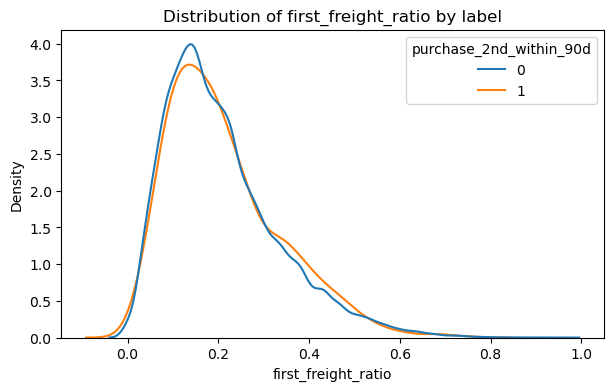

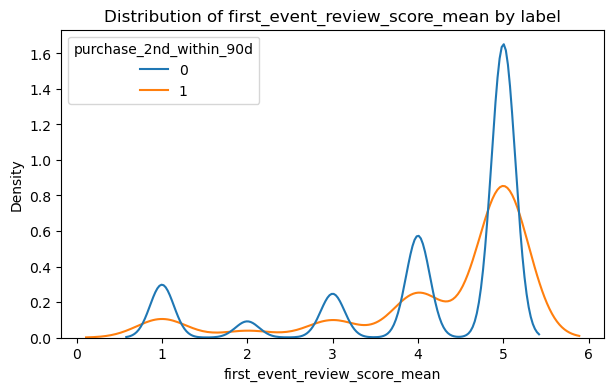

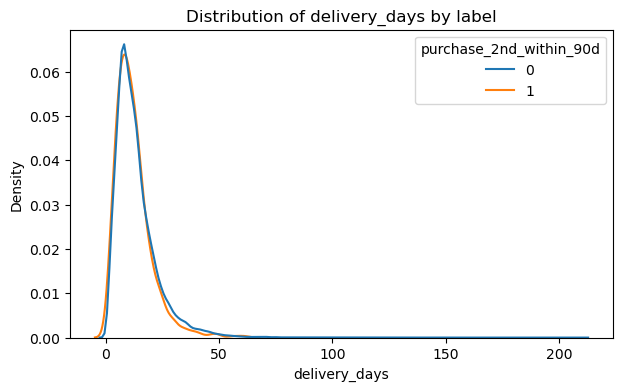

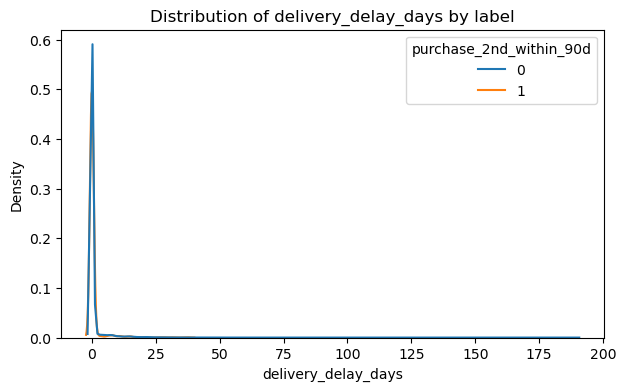

In [16]:
for col in num_cols:
    plt.figure(figsize=(7, 4))
    sns.kdeplot(
        data=abt_2nd_purchase,
        x=col,
        hue="purchase_2nd_within_90d",
        common_norm=False
    )
    plt.title(f"Distribution of {col} by label")
    plt.show()

### 2. overview分析(類別欄位):分析哪些變量會影響回購意願


===== same_ts_multi_order_flag =====
   same_ts_multi_order_flag  count  repurchase_rate_90d
0                         0  74695             0.014579
1                         1    625             0.036800


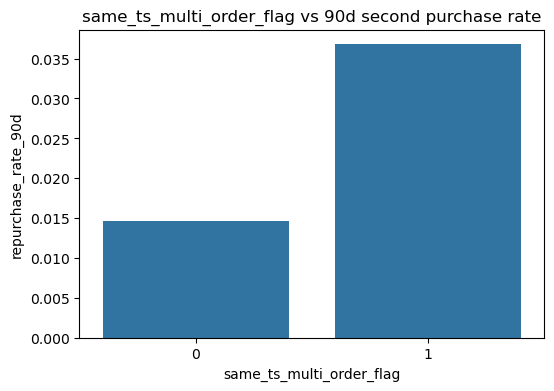


===== has_review =====
   has_review  count  repurchase_rate_90d
0           0    532             0.007519
1           1  74788             0.014815


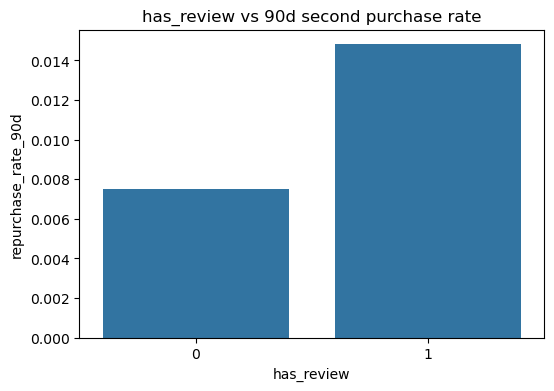


===== late_flag =====
   late_flag  count  repurchase_rate_90d
0          0  68680             0.015055
1          1   6640             0.011747


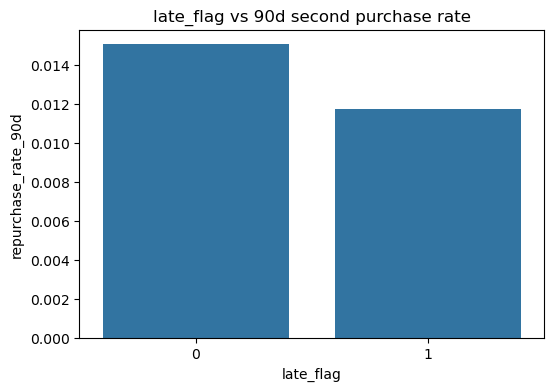

In [17]:
cat_binary_cols = [
    "same_ts_multi_order_flag",
    "has_review",
    "late_flag"
]

for col in cat_binary_cols:
    out = (
        abt_2nd_purchase.groupby(col)["purchase_2nd_within_90d"]
        .agg(["count", "mean"])
        .reset_index()
        .rename(columns={"mean": "repurchase_rate_90d"})
    )

    print(f"\n===== {col} =====")
    print(out)

    plt.figure(figsize=(6, 4))
    sns.barplot(data=out, x=col, y="repurchase_rate_90d")
    plt.title(f"{col} vs 90d second purchase rate")
    plt.show()

1. same_ts_multi_order_flag  
0：回購率1.4579%  
1：回購率3.6800%  

差距約 +2.22 個百分點  
相對比例約 2.5 倍  
首購時若同一 timestamp 出現多筆 order，後續 90 天內二購率明顯更高。

2. has_review  
0：回購率0.7519%  
1：回購率1.4815%  

差距約 +0.73 個百分點  
相對比例約 約 1.97 倍  
首購後有 review 資料的人，二購率約是無 review 者的 2 倍。

3. late_flag  
0：回購率1.5055%  
1：回購率1.1747%  

差距約 -0.33 個百分點  
延遲交付的首購客，二購率較低。

### 3. 顧客所在地區會影響90天回購率？

In [18]:
state_repurchase = (
    abt_2nd_purchase
    .groupby("customer_state")["purchase_2nd_within_90d"]
    .agg(
        customer_cnt="count",
        repurchase_rate_90d="mean"
    )
    .reset_index()
)

# 可選：排除樣本過少州，避免噪音
state_repurchase = state_repurchase.loc[
    state_repurchase["customer_cnt"] >= 500
].copy()

# 排序
state_repurchase = state_repurchase.sort_values(
    "repurchase_rate_90d",
    ascending=False
)

print(state_repurchase)

   customer_state  customer_cnt  repurchase_rate_90d
7              ES          1587             0.022054
12             MT           714             0.019608
25             SP         30791             0.016109
8              GO          1576             0.015228
4              BA          2573             0.015157
18             RJ          9864             0.015105
10             MG          9004             0.014105
22             RS          4289             0.013989
6              DF          1576             0.013325
11             MS           551             0.012704
17             PR          3851             0.012464
15             PE          1247             0.011227
5              CE          1050             0.010476
23             SC          2864             0.010475
13             PA           771             0.007782
9              MA           590             0.005085


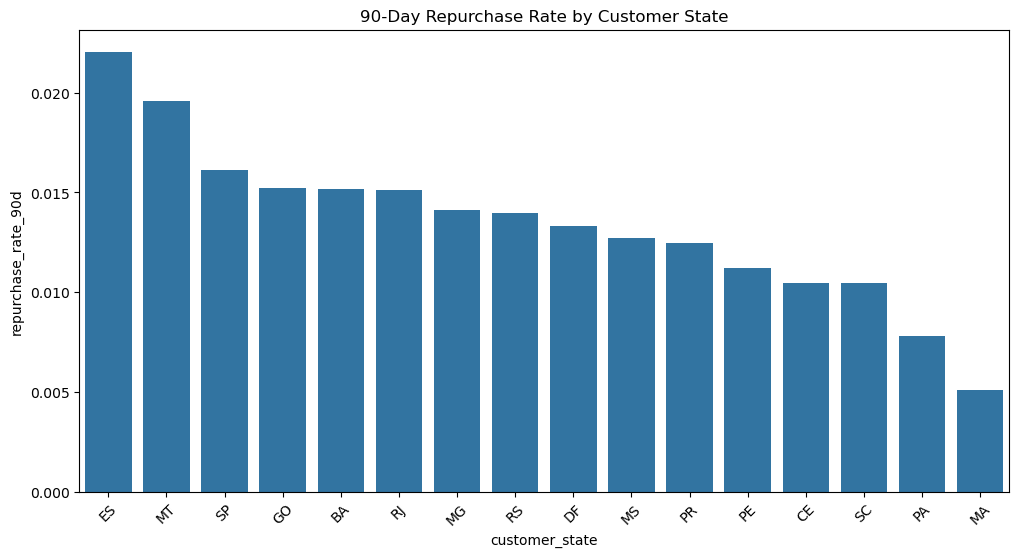

In [19]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=state_repurchase,
    x="customer_state",
    y="repurchase_rate_90d"
)

plt.title("90-Day Repurchase Rate by Customer State")
plt.xticks(rotation=45)
plt.show()

In [20]:
baseline = abt_2nd_purchase["purchase_2nd_within_90d"].mean()
print("整體顧客90天回購率:", baseline)

整體顧客90天回購率: 0.014763674986723313


In [21]:
pd.set_option('display.max_columns', None)  # 顯示所有欄

In [22]:
num_summary

first_purchase_gmv                                   \
                                     count        mean   median         std   
purchase_2nd_within_90d                                                       
0                                    74208  160.852733  105.610  219.492500   
1                                     1112  154.502014  104.675  175.956816   

                        first_item_cnt                             \
                                 count      mean median       std   
purchase_2nd_within_90d                                             
0                                74208  1.150024    1.0  0.550822   
1                                 1112  1.271583    1.0  0.870551   

                        first_category_cnt                             \
                                     count      mean median       std   
purchase_2nd_within_90d                                                 
0                                    74208  0.993586    1.0  0.161060   
1                                     1112  1.011691    1.0  0.191747   

                        seller_cnt                             \
                             count      mean median       std   
purchase_2nd_within_90d                                         
0                            74208  1.018138    1.0  0.140822   
1                             1112  1.036871    1.0  0.197847   

                        first_freight_ratio                                \
                                      count      mean    median       std   
purchase_2nd_within_90d                                                     
0                                     74208  0.206583  0.181465  0.125160   
1                                      1112  0.212255  0.185693  0.124235   

                        first_event_review_score_mean                   \
                                                count      mean median   
purchase_2nd_within_90d                                                  
0                                               73680  4.114151    5.0   
1                                                1108  4.270532    5.0   

                                  delivery_days                        \
                              std         count       mean     median   
purchase_2nd_within_90d                                                 
0                        1.309177         74206  13.528542  11.199306   
1                        1.203435          1112  12.225758  10.512847   

                                   delivery_delay_days                   \
                               std               count      mean median   
purchase_2nd_within_90d                                                   
0                        10.065706               74206  0.904488    0.0   
1                         8.053673                1112  0.582966    0.0   

                                   
                              std  
purchase_2nd_within_90d            
0                        5.237969  
1                        3.058660

In [23]:
abt_2nd_purchase

,customer_unique_id,first_purchase_ts,purchase_month,customer_state,same_ts_multi_order_flag,first_purchase_gmv,first_item_cnt,first_category_cnt,seller_cnt,first_freight_ratio,has_review,first_event_review_score_mean,delivery_days,delivery_delay_days,late_flag,second_purchase_ts,days_to_2nd_purchase,purchase_2nd_within_90d
0,0000366f3b9a7992bf8c76cfdf3221e2,2018-05-10 10:56:00,2018-05-01,SP,0,141.90,1,1,1,0.084567,1,5.0,6.411111,0.0,0,NaT,NaN,0
1,0000b849f77a49e4a4ce2b2a4ca5be3f,2018-05-07 11:11:00,2018-05-01,SP,0,27.19,1,1,1,0.304892,1,4.0,3.285417,0.0,0,NaT,NaN,0
2,0000f46a3911fa3c0805444483337064,2017-03-10 21:05:00,2017-03-01,SC,0,86.22,1,1,1,0.199722,1,3.0,25.731250,0.0,0,NaT,NaN,0
3,0000f6ccb0745a6a4b88665a16c9f078,2017-10-12 20:29:00,2017-10-01,PA,0,43.62,1,1,1,0.404172,1,4.0,20.037500,0.0,0,NaT,NaN,0
4,0004aac84e0df4da2b147fca70cf8255,2017-11-14 19:45:00,2017-11-01,SP,0,196.89,1,1,1,0.085784,1,5.0,13.140972,0.0,0,NaT,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
93353,fffcf5a5ff07b0908bd4e2dbc735a684,2017-06-08 21:00:00,2017-06-01,PE,0,2067.42,2,1,1,0.240599,1,5.0,27.515278,0.0,0,NaT,NaN,0
93354,fffea47cd6d3cc0a88bd621562a9d061,2017-12-10 20:07:00,2017-12-01,BA,0,84.58,1,1,1,0.232797,1,4.0,30.097917,0.0,0,NaT,NaN,0
93355,ffff371b4d645b6ecea244b27531430a,2017-02-07 15:49:00,2017-02-01,MT,0,112.46,1,1,1,0.200605,1,5.0,14.872222,0.0,0,NaT,NaN,0
93356,ffff5962728ec6157033ef9805bacc48,2018-05-02 15:17:00,2018-05-01,ES,0,133.69,1,1,1,0.139801,1,5.0,11.859028,0.0,0,NaT,NaN,0


### 4. 顧客體驗品質會如何影響90天二購率？  


- 4.1評分水準會影響回購？
| 分組 | 定義  |
| -- | --- |
| 低分 | 1–2 |
| 中分 | 3   |
| 高分 | 4–5 |

In [24]:
abt_2nd_purchase.columns

Index(['customer_unique_id', 'first_purchase_ts', 'purchase_month',
       'customer_state', 'same_ts_multi_order_flag', 'first_purchase_gmv',
       'first_item_cnt', 'first_category_cnt', 'seller_cnt',
       'first_freight_ratio', 'has_review', 'first_event_review_score_mean',
       'delivery_days', 'delivery_delay_days', 'late_flag',
       'second_purchase_ts', 'days_to_2nd_purchase',
       'purchase_2nd_within_90d'],
      dtype='object')

In [25]:


df = abt_2nd_purchase.copy()

# 只保留有 review 的樣本
review_df = df.loc[df["first_event_review_score_mean"].notna()].copy()

# 分組：低 / 中 / 高
review_df["review_group"] = pd.cut(
    review_df["first_event_review_score_mean"],
    bins=[0, 2, 3, 5],
    labels=["low_1_2", "mid_3", "high_4_5"],
    include_lowest=True,
    right=True
)

# 計算 summary
review_group_summary = (
    review_df.groupby("review_group", observed=False)
    .agg(
        customer_cnt=("customer_unique_id", "count"),
        repurchase_cnt=("purchase_2nd_within_90d", "sum"),
        repurchase_rate=("purchase_2nd_within_90d", "mean"),
        review_score_mean=("first_event_review_score_mean", "mean")
    )
    .reset_index()
)

# 轉 %
review_group_summary["repurchase_rate"] = (
    review_group_summary["repurchase_rate"] * 100
).round(2)

review_group_summary["customer_rate"] = (
    review_group_summary["customer_cnt"] / review_group_summary["customer_cnt"].sum() * 100
).round(2)

review_group_summary

,review_group,customer_cnt,repurchase_cnt,repurchase_rate,review_score_mean,customer_rate
0,low_1_2,10131,117,1.15,1.235457,13.55
1,mid_3,6451,82,1.27,2.997985,8.63
2,high_4_5,58206,909,1.56,4.741882,77.83


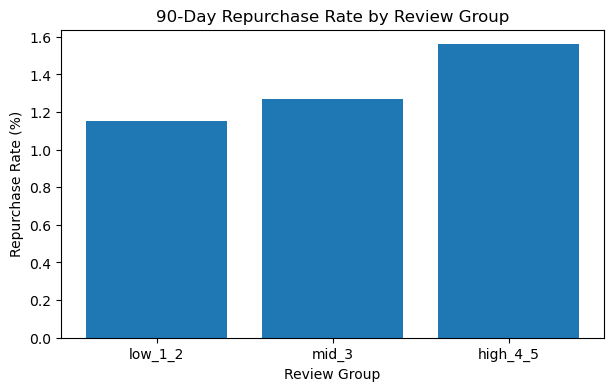

In [26]:
plot_df = review_group_summary.copy()

plt.figure(figsize=(7,4))
plt.bar(plot_df["review_group"].astype(str), plot_df["repurchase_rate"])
plt.xlabel("Review Group")
plt.ylabel("Repurchase Rate (%)")
plt.title("90-Day Repurchase Rate by Review Group")
plt.show()

- 4.2低分是否是關鍵風險訊號？

In [27]:
df = abt_2nd_purchase.copy()

# 只保留有 review 的樣本
review_df = df.loc[df["first_event_review_score_mean"].notna()].copy()

# 定義低分旗標：<=3 視為低分風險
review_df["low_score_flag"] = (
    review_df["first_event_review_score_mean"] <= 3
).astype(int)

# 比較 low vs non-low 的二購率
low_score_summary = (
    review_df.groupby("low_score_flag")
    .agg(
        customer_cnt=("customer_unique_id", "count"),
        repurchase_cnt=("purchase_2nd_within_90d", "sum"),
        repurchase_rate=("purchase_2nd_within_90d", "mean"),
        review_score_mean=("first_event_review_score_mean", "mean")
    )
    .reset_index()
)

low_score_summary["repurchase_rate"] = (
    low_score_summary["repurchase_rate"] * 100
).round(2)

low_score_summary["customer_rate"] = (
    low_score_summary["customer_cnt"] / low_score_summary["customer_cnt"].sum() * 100
).round(2)

low_score_summary["group_name"] = low_score_summary["low_score_flag"].map({
    1: "low_score_<=3",
    0: "non_low_score_>3"
})
low_score_summary


,low_score_flag,customer_cnt,repurchase_cnt,repurchase_rate,review_score_mean,customer_rate,group_name
0,0,58206,909,1.56,4.741882,77.83,non_low_score_>3
1,1,16582,199,1.20,1.921144,22.17,low_score_<=3


In [28]:
# 取出兩組二購率
rate_low = low_score_summary.loc[
    low_score_summary["low_score_flag"] == 1, "repurchase_rate"
].iloc[0]

rate_non_low = low_score_summary.loc[
    low_score_summary["low_score_flag"] == 0, "repurchase_rate"
].iloc[0]

# 絕對差距（百分點）
abs_diff = round(rate_non_low - rate_low, 2)

# 相對倍數
relative_ratio = round(rate_non_low / rate_low, 2) if rate_low != 0 else np.nan

print("非低分組 / 低分組 二購率倍數:", relative_ratio)

非低分組 / 低分組 二購率倍數: 1.3


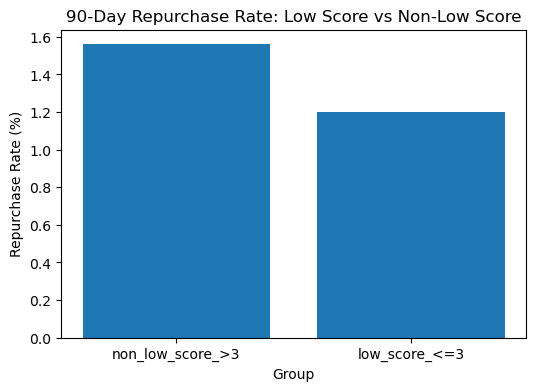

In [29]:

plot_df = low_score_summary.copy()

plt.figure(figsize=(6,4))
plt.bar(plot_df["group_name"], plot_df["repurchase_rate"])
plt.xlabel("Group")
plt.ylabel("Repurchase Rate (%)")
plt.title("90-Day Repurchase Rate: Low Score vs Non-Low Score")
plt.show()

- 4.3首購後有沒有留下評論，是否能作為二購傾向的早期訊號？

In [30]:

df = abt_2nd_purchase.copy()

has_review_summary = (
    df.groupby("has_review")
    .agg(
        customer_cnt=("customer_unique_id", "count"),
        repurchase_cnt=("purchase_2nd_within_90d", "sum"),
        repurchase_rate=("purchase_2nd_within_90d", "mean")
    )
    .reset_index()
)

has_review_summary["repurchase_rate"] = (
    has_review_summary["repurchase_rate"] * 100
).round(2)

has_review_summary["customer_rate"] = (
    has_review_summary["customer_cnt"] / has_review_summary["customer_cnt"].sum() * 100
).round(2)

has_review_summary["group_name"] = has_review_summary["has_review"].map({
    0: "no_review",
    1: "has_review"
})

has_review_summary

,has_review,customer_cnt,repurchase_cnt,repurchase_rate,customer_rate,group_name
0,0,532,4,0.75,0.71,no_review
1,1,74788,1108,1.48,99.29,has_review


In [31]:
rate_no_review = has_review_summary.loc[
    has_review_summary["has_review"] == 0, "repurchase_rate"
].iloc[0]

rate_has_review = has_review_summary.loc[
    has_review_summary["has_review"] == 1, "repurchase_rate"
].iloc[0]

abs_diff = round(rate_has_review - rate_no_review, 2)
relative_ratio = round(rate_has_review / rate_no_review, 2) if rate_no_review != 0 else np.nan

print("有評論 - 無評論 二購率差距（百分點）:", abs_diff)
print("有評論 / 無評論 二購率倍數:", relative_ratio)

有評論 - 無評論 二購率差距（百分點）: 0.73
有評論 / 無評論 二購率倍數: 1.97


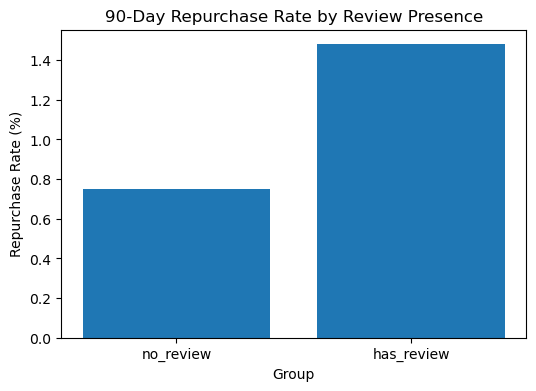

In [32]:

plot_df = has_review_summary.copy()

plt.figure(figsize=(6,4))
plt.bar(plot_df["group_name"], plot_df["repurchase_rate"])
plt.xlabel("Group")
plt.ylabel("Repurchase Rate (%)")
plt.title("90-Day Repurchase Rate by Review Presence")
plt.show()

- 4.4review 與物流體驗是否交互影響？
    1. 物流體驗是否影響評分？
    2. Review × 延遲交叉後，二購率如何變化？
    3. 評分與物流是否為獨立訊號？

1. 物流體驗是否影響評分？
  | 群組 | 定義        |
| -- | --------- |
| A  | 非低分 + 未延遲 |
| B  | 非低分 + 延遲  |
| C  | 低分 + 未延遲  |
| D  | 低分 + 延遲   |



In [33]:


df = abt_2nd_purchase.copy()

# 只保留有 review 的樣本
q4_df = df.loc[df["first_event_review_score_mean"].notna()].copy()

# 定義低分旗標
q4_df["low_score_flag"] = (
    q4_df["first_event_review_score_mean"] <= 3
).astype(int)

# late_flag vs low_score_rate
late_review_summary = (
    q4_df.groupby("late_flag")
    .agg(
        customer_cnt=("customer_unique_id", "count"),
        low_score_cnt=("low_score_flag", "sum"),
        low_score_rate=("low_score_flag", "mean"),
        review_score_mean=("first_event_review_score_mean", "mean"),
        repurchase_rate=("purchase_2nd_within_90d", "mean")
    )
    .reset_index()
)

late_review_summary["low_score_rate"] = (late_review_summary["low_score_rate"] * 100).round(2)
late_review_summary["repurchase_rate"] = (late_review_summary["repurchase_rate"] * 100).round(2)

late_review_summary["group_name"] = late_review_summary["late_flag"].map({
    0: "not_late",
    1: "late"
})

late_review_summary

,late_flag,customer_cnt,low_score_cnt,low_score_rate,review_score_mean,repurchase_rate,group_name
0,0,68285,12110,17.73,4.275822,1.51,not_late
1,1,6503,4472,68.77,2.443167,1.17,late


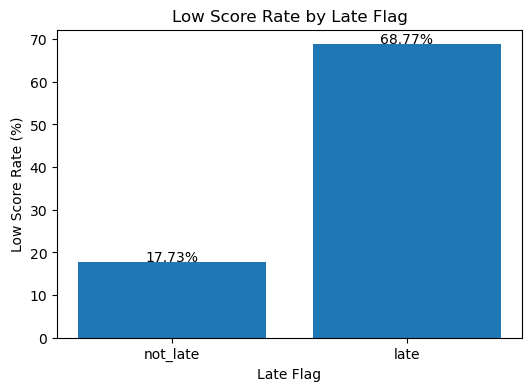

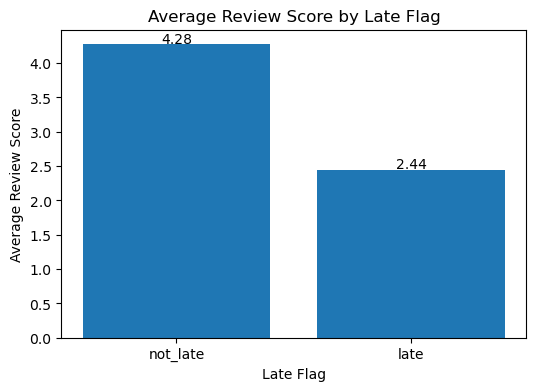

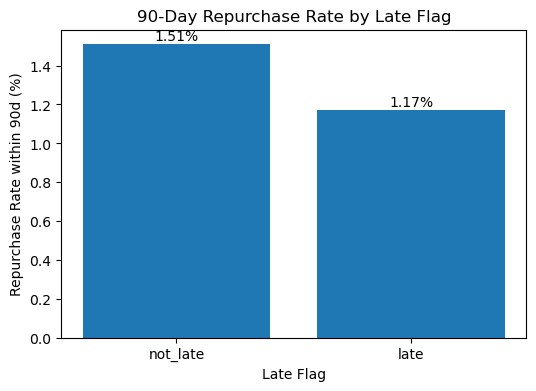

In [34]:


plot_df = late_review_summary.copy()

# 圖1：延遲 vs 低分率
plt.figure(figsize=(6,4))
plt.bar(plot_df["group_name"], plot_df["low_score_rate"])
plt.xlabel("Late Flag")
plt.ylabel("Low Score Rate (%)")
plt.title("Low Score Rate by Late Flag")
for i, v in enumerate(plot_df["low_score_rate"]):
    plt.text(i, v + 0.2, f"{v:.2f}%", ha="center")
plt.show()

# 圖2：延遲 vs 平均評分
plt.figure(figsize=(6,4))
plt.bar(plot_df["group_name"], plot_df["review_score_mean"])
plt.xlabel("Late Flag")
plt.ylabel("Average Review Score")
plt.title("Average Review Score by Late Flag")
for i, v in enumerate(plot_df["review_score_mean"]):
    plt.text(i, v + 0.02, f"{v:.2f}", ha="center")
plt.show()

# 圖3：延遲 vs 90天二購率
plt.figure(figsize=(6,4))
plt.bar(plot_df["group_name"], plot_df["repurchase_rate"])
plt.xlabel("Late Flag")
plt.ylabel("Repurchase Rate within 90d (%)")
plt.title("90-Day Repurchase Rate by Late Flag")
for i, v in enumerate(plot_df["repurchase_rate"]):
    plt.text(i, v + 0.02, f"{v:.2f}%", ha="center")
plt.show()

2. Review × 延遲交叉後，二購率如何變化？
   | 群組                 | 定義        |
| ------------------ | --------- |
| `non_low_review_not_late` | 非低分 + 未延遲 |
| `non_low_review_late`     | 非低分 + 延遲  |
| `low_review_not_late`     | 低分 + 未延遲  |
| `low_review_late`         | 低分 + 延遲   |

low_score_flag = 1：評分 <= 3  
late_flag = 1：有延遲


In [35]:

df = abt_2nd_purchase.copy()

# 只保留有 review 的樣本
q4_df = df.loc[df["first_event_review_score_mean"].notna()].copy()

# 定義低分旗標
q4_df["low_score_flag"] = (
    q4_df["first_event_review_score_mean"] <= 3
).astype(int)

# 建立四群組（命名優化）
q4_df["review_delay_group"] = np.select(
    [
        (q4_df["low_score_flag"] == 0) & (q4_df["late_flag"] == 0),
        (q4_df["low_score_flag"] == 0) & (q4_df["late_flag"] == 1),
        (q4_df["low_score_flag"] == 1) & (q4_df["late_flag"] == 0),
        (q4_df["low_score_flag"] == 1) & (q4_df["late_flag"] == 1),
    ],
    [
        "non_low_review_not_late",
        "non_low_review_late",
        "low_review_not_late",
        "low_review_late"
    ],
    default="other"
)

# summary
review_delay_summary = (
    q4_df.groupby("review_delay_group")
    .agg(
        customer_cnt=("customer_unique_id", "count"),
        repurchase_cnt=("purchase_2nd_within_90d", "sum"),
        repurchase_rate=("purchase_2nd_within_90d", "mean"),
        review_score_mean=("first_event_review_score_mean", "mean"),
        delivery_delay_mean=("delivery_delay_days", "mean"),
        delivery_days_mean=("delivery_days", "mean")
    )
    .reset_index()
)

# 轉 %
review_delay_summary["repurchase_rate"] = (
    review_delay_summary["repurchase_rate"] * 100
).round(2)

review_delay_summary["customer_rate"] = (
    review_delay_summary["customer_cnt"] / review_delay_summary["customer_cnt"].sum() * 100
).round(2)

# 排序（建議用固定順序，不要用 repurchase_rate）
order = [
    "non_low_review_not_late",
    "non_low_review_late",
    "low_review_not_late",
    "low_review_late"
]

review_delay_summary["review_delay_group"] = pd.Categorical(
    review_delay_summary["review_delay_group"],
    categories=order,
    ordered=True
)

review_delay_summary = review_delay_summary.sort_values("review_delay_group").reset_index(drop=True)

review_delay_summary

,review_delay_group,customer_cnt,repurchase_cnt,repurchase_rate,review_score_mean,delivery_delay_mean,delivery_days_mean,customer_rate
0,non_low_review_not_late,56175,881,1.57,4.746292,0.000000,11.226893,75.11
1,non_low_review_late,2031,28,1.38,4.619892,6.172794,28.589572,2.72
2,low_review_not_late,12110,151,1.25,2.093435,0.000000,13.030643,16.19
3,low_review_late,4472,48,1.07,1.454588,11.868810,35.877611,5.98


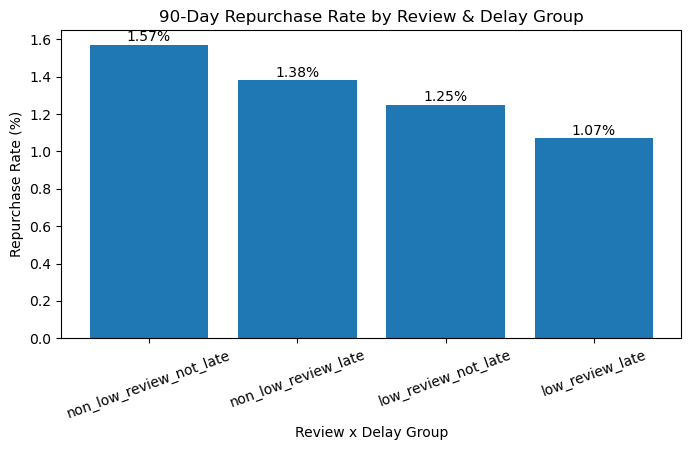

In [36]:
plot_df = review_delay_summary.copy()

plt.figure(figsize=(8,4))
plt.bar(plot_df["review_delay_group"], plot_df["repurchase_rate"])
plt.xlabel("Review x Delay Group")
plt.ylabel("Repurchase Rate (%)")
plt.title("90-Day Repurchase Rate by Review & Delay Group")
plt.xticks(rotation=20)

for i, v in enumerate(plot_df["repurchase_rate"]):
    plt.text(i, v + 0.02, f"{v:.2f}%", ha="center")

plt.show()

## 5. 地區特徵與回購

### Q1：地區差異
#### 1.1 各州二購率

### Q2：地區 vs 物流 / 體驗
#### 2.1 州別物流與體驗差異
#### 2.2 地區差異 vs 物流
#### 2.3 控制物流與評分後的差異

### Q3：商業意義

In [37]:
# 1.1區是否存在明顯二購率差異？

df = abt_2nd_purchase.copy()

state_repurchase_summary = (
    df.groupby("customer_state")
    .agg(
        customer_cnt=("customer_unique_id", "count"),
        repurchase_cnt=("purchase_2nd_within_90d", "sum"),
        repurchase_rate=("purchase_2nd_within_90d", "mean")
    )
    .reset_index()
)

state_repurchase_summary["repurchase_rate"] = (
    state_repurchase_summary["repurchase_rate"] * 100
).round(2)

state_repurchase_summary = state_repurchase_summary.sort_values(
    ["repurchase_rate", "customer_cnt"],
    ascending=[False, False]
).reset_index(drop=True)

state_repurchase_summary

,customer_state,customer_cnt,repurchase_cnt,repurchase_rate
0,ES,1587,35,2.21
1,MT,714,14,1.96
2,AP,56,1,1.79
3,SP,30791,496,1.61
4,PI,385,6,1.56
5,RO,195,3,1.54
6,BA,2573,39,1.52
7,GO,1576,24,1.52
8,AC,66,1,1.52
9,RJ,9864,149,1.51


可以看到有幾個州的樣本數過少

In [38]:
# 先看 customer_cnt >= 500 的州，避免太小樣本干擾。

state_repurchase_filtered = (
    state_repurchase_summary.loc[state_repurchase_summary["customer_cnt"] >= 500]
    .copy()
    .reset_index(drop=True)
)

state_repurchase_filtered

,customer_state,customer_cnt,repurchase_cnt,repurchase_rate
0,ES,1587,35,2.21
1,MT,714,14,1.96
2,SP,30791,496,1.61
3,BA,2573,39,1.52
4,GO,1576,24,1.52
5,RJ,9864,149,1.51
6,MG,9004,127,1.41
7,RS,4289,60,1.40
8,DF,1576,21,1.33
9,MS,551,7,1.27


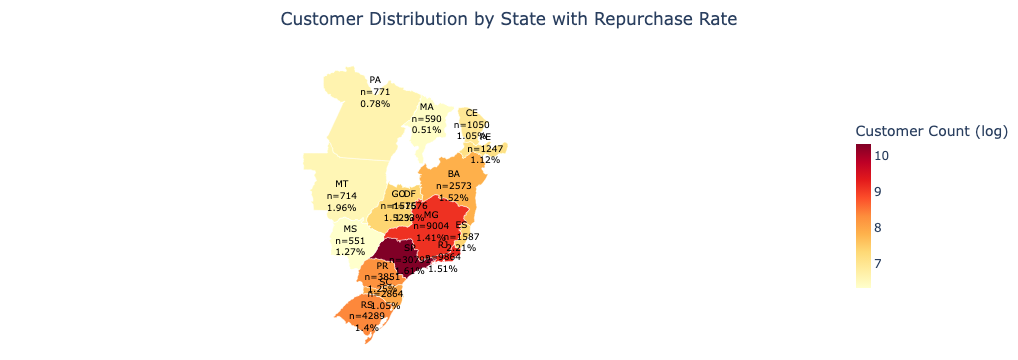

In [39]:
import requests
import plotly.express as px
import plotly.graph_objects as go

# 1. 準備資料
plot_df = state_repurchase_filtered.copy()

# 熱力圖用 log scale，避免 SP 壓掉其他州
plot_df["log_customer_cnt"] = np.log1p(plot_df["customer_cnt"])

# 2. 讀取巴西州 geojson
url = "https://raw.githubusercontent.com/codeforamerica/click_that_hood/master/public/data/brazil-states.geojson"
geojson = requests.get(url).json()

# 3. 從 geojson 計算各州文字標籤中心點
centroids = []
for feature in geojson["features"]:
    state = feature["properties"]["sigla"]
    geom_type = feature["geometry"]["type"]
    coords = feature["geometry"]["coordinates"]

    if geom_type == "MultiPolygon":
        polygon = coords[0][0]
    else:
        polygon = coords[0]

    lon = np.mean([pt[0] for pt in polygon])
    lat = np.mean([pt[1] for pt in polygon])

    centroids.append({
        "customer_state": state,
        "lon": lon,
        "lat": lat
    })

centroid_df = pd.DataFrame(centroids)

# 4. 合併中心點資料，建立文字標籤
label_df = plot_df.merge(centroid_df, on="customer_state", how="left")
label_df["label_text"] = (
    label_df["customer_state"] +
    "<br>n=" + label_df["customer_cnt"].astype(str) +
    "<br>" + label_df["repurchase_rate"].astype(str) + "%"
)

# 5. 畫熱力圖
fig = px.choropleth(
    plot_df,
    geojson=geojson,
    locations="customer_state",
    featureidkey="properties.sigla",
    color="log_customer_cnt",
    color_continuous_scale="YlOrRd",
    hover_name="customer_state",
    hover_data={
        "customer_cnt": True,
        "repurchase_rate": True,
        "log_customer_cnt": False
    }
)

# 6. 疊上州簡寫、樣本數、回購率
fig.add_trace(
    go.Scattergeo(
        lon=label_df["lon"],
        lat=label_df["lat"],
        text=label_df["label_text"],
        mode="text",
        textfont=dict(
            size=9,
            color="black"
        ),
        hoverinfo="skip"
    )
)

# 7. 美化地圖
fig.update_geos(
    fitbounds="locations",
    visible=False,
    showcountries=True,
    countrycolor="white"
)

fig.update_traces(marker_line_width=0.5, marker_line_color="white")

fig.update_layout(
    title={
        "text": "Customer Distribution by State with Repurchase Rate",
        "x": 0.5,
        "xanchor": "center"
    },
    coloraxis_colorbar=dict(
        title="Customer Count (log)",
        thickness=15,
        len=0.6
    ),
    margin={"r": 0, "t": 50, "l": 0, "b": 0},
    paper_bgcolor="white"
)

fig.show()

In [40]:
output_path = "/Users/kaiping/Desktop/olist_project/graphs/圖"

# 確保資料夾存在（避免報錯）
os.makedirs(output_path, exist_ok=True)

# 輸出互動圖
fig.write_html(f"{output_path}/brazil_map.html")

In [41]:
# 2.1不同州的物流與體驗表現是否有差？
df = abt_2nd_purchase.copy()

# 1. 只保留樣本數 >= 500 的州
valid_states = state_repurchase_filtered["customer_state"].unique()
state_df = df.loc[df["customer_state"].isin(valid_states)].copy()

# 2. 建立低分旗標（只對有 review 的樣本判定）
state_df["low_score_flag"] = (
    state_df["first_event_review_score_mean"] <= 3
).astype(int)

# 3. 各州物流與體驗指標 summary
state_experience_summary = (
    state_df.groupby("customer_state")
    .agg(
        customer_cnt=("customer_unique_id", "count"),
        repurchase_cnt=("purchase_2nd_within_90d", "sum"),
        repurchase_rate=("purchase_2nd_within_90d", "mean"),

        avg_delivery_days=("delivery_days", "mean"),
        avg_delivery_delay_days=("delivery_delay_days", "mean"),
        late_rate=("late_flag", "mean"),

        avg_review_score=("first_event_review_score_mean", "mean"),
        low_score_rate=("low_score_flag", "mean")
    )
    .reset_index()
)

# 4. 百分比轉換
state_experience_summary["repurchase_rate"] = (
    state_experience_summary["repurchase_rate"] * 100
).round(2)

state_experience_summary["late_rate"] = (
    state_experience_summary["late_rate"] * 100
).round(2)

state_experience_summary["low_score_rate"] = (
    state_experience_summary["low_score_rate"] * 100
).round(2)

# 5. 數值欄位四捨五入
for col in ["avg_delivery_days", "avg_delivery_delay_days", "avg_review_score"]:
    state_experience_summary[col] = state_experience_summary[col].round(2)

# 6. 依二購率排序方便觀察
state_experience_summary = state_experience_summary.sort_values(
    "repurchase_rate", ascending=False
).reset_index(drop=True)

state_experience_summary

,customer_state,customer_cnt,repurchase_cnt,repurchase_rate,avg_delivery_days,avg_delivery_delay_days,late_rate,avg_review_score,low_score_rate
0,ES,1587,35,2.21,16.56,1.48,13.80,4.04,24.01
1,MT,714,14,1.96,19.03,0.79,8.12,4.11,21.85
2,SP,30791,496,1.61,9.38,0.45,5.46,4.23,19.03
3,BA,2573,39,1.52,20.42,1.76,16.01,3.86,28.76
4,GO,1576,24,1.52,16.47,0.92,9.26,4.06,23.98
5,RJ,9864,149,1.51,16.52,2.04,15.41,3.90,28.09
6,MG,9004,127,1.41,12.87,0.50,6.54,4.16,20.87
7,RS,4289,60,1.40,16.23,0.76,8.21,4.14,21.26
8,DF,1576,21,1.33,13.95,0.50,7.93,4.09,22.34
9,MS,551,7,1.27,16.37,0.98,11.62,4.13,21.78


2.1 州別物流與體驗差異
| 欄位                                   | 意義             |
| ------------------------------------ | -------------- |
| `customer_unique_id`                 | 顧客唯一 ID        |
| `customer_state`                     | 顧客所在州          |
| `first_purchase_ts`                  | 首購時間           |
| `first_purchase_delivery_days`       | 首購配送天數         |
| `first_purchase_delivery_delay_days` | 首購延遲天數         |
| `first_purchase_late_flag`           | 首購是否延遲         |
| `first_purchase_review_score_mean`   | 首購事件平均評分       |
| `first_purchase_low_score_flag`      | 首購是否低分，評分 <= 2 |
| `repurchase_2nd_within_90d_flag`     | 首購後 90 天內是否二購  |



In [42]:
abt_2nd_purchase.columns

Index(['customer_unique_id', 'first_purchase_ts', 'purchase_month',
       'customer_state', 'same_ts_multi_order_flag', 'first_purchase_gmv',
       'first_item_cnt', 'first_category_cnt', 'seller_cnt',
       'first_freight_ratio', 'has_review', 'first_event_review_score_mean',
       'delivery_days', 'delivery_delay_days', 'late_flag',
       'second_purchase_ts', 'days_to_2nd_purchase',
       'purchase_2nd_within_90d'],
      dtype='object')

In [43]:
# =========================
# 2.1 州別物流與體驗差異：清洗分析資料
# =========================
# 1. 複製資料
state_logistics_experience_base = abt_2nd_purchase.copy()

# 2. 欄位重新命名：讓語意更具體
state_logistics_experience_base = state_logistics_experience_base.rename(
    columns={
        "first_event_review_score_mean": "first_purchase_review_score_mean",
        "delivery_days": "first_purchase_delivery_days",
        "delivery_delay_days": "first_purchase_delivery_delay_days",
        "late_flag": "first_purchase_late_flag",
        "purchase_2nd_within_90d": "repurchase_2nd_within_90d_flag"
    }
)

# 3. 保留本節需要欄位
state_logistics_experience_base = state_logistics_experience_base[
    [
        "customer_unique_id",
        "customer_state",
        "first_purchase_ts",
        "first_purchase_delivery_days",
        "first_purchase_delivery_delay_days",
        "first_purchase_late_flag",
        "first_purchase_review_score_mean",
        "repurchase_2nd_within_90d_flag"
    ]
].copy()

# 4. 型態清理
numeric_cols = [
    "first_purchase_delivery_days",
    "first_purchase_delivery_delay_days",
    "first_purchase_late_flag",
    "first_purchase_review_score_mean",
    "repurchase_2nd_within_90d_flag"
]

for col in numeric_cols:
    state_logistics_experience_base[col] = pd.to_numeric(
        state_logistics_experience_base[col],
        errors="coerce"
    )

state_logistics_experience_base["first_purchase_ts"] = pd.to_datetime(
    state_logistics_experience_base["first_purchase_ts"],
    errors="coerce"
)

# 5. 建立低分評價欄位：review_score <= 2
state_logistics_experience_base["first_purchase_low_score_flag"] = (
    state_logistics_experience_base["first_purchase_review_score_mean"] <= 2
).astype(int)

# 6. 移除州別缺失
state_logistics_experience_base = state_logistics_experience_base.dropna(
    subset=["customer_state"]
).copy()

# 7. 基本檢查
print("資料筆數:", state_logistics_experience_base.shape[0])
print("欄位數:", state_logistics_experience_base.shape[1])

print("\n欄位清單:")
print(state_logistics_experience_base.columns.tolist())

print("\n缺值率:")
display(
    state_logistics_experience_base
    .isna()
    .mean()
    .sort_values(ascending=False)
    .reset_index()
    .rename(columns={"index": "column_name", 0: "missing_rate"})
)

state_logistics_experience_base.head()

資料筆數: 75320
欄位數: 9

欄位清單:
['customer_unique_id', 'customer_state', 'first_purchase_ts', 'first_purchase_delivery_days', 'first_purchase_delivery_delay_days', 'first_purchase_late_flag', 'first_purchase_review_score_mean', 'repurchase_2nd_within_90d_flag', 'first_purchase_low_score_flag']

缺值率:


,column_name,missing_rate
0,first_purchase_review_score_mean,0.007063
1,first_purchase_delivery_days,0.000027
2,first_purchase_delivery_delay_days,0.000027
3,customer_unique_id,0.000000
4,customer_state,0.000000
5,first_purchase_ts,0.000000
6,first_purchase_late_flag,0.000000
7,repurchase_2nd_within_90d_flag,0.000000
8,first_purchase_low_score_flag,0.000000


,customer_unique_id,customer_state,first_purchase_ts,first_purchase_delivery_days,first_purchase_delivery_delay_days,first_purchase_late_flag,first_purchase_review_score_mean,repurchase_2nd_within_90d_flag,first_purchase_low_score_flag
0,0000366f3b9a7992bf8c76cfdf3221e2,SP,2018-05-10 10:56:00,6.411111,0.0,0,5.0,0,0
1,0000b849f77a49e4a4ce2b2a4ca5be3f,SP,2018-05-07 11:11:00,3.285417,0.0,0,4.0,0,0
2,0000f46a3911fa3c0805444483337064,SC,2017-03-10 21:05:00,25.731250,0.0,0,3.0,0,0
3,0000f6ccb0745a6a4b88665a16c9f078,PA,2017-10-12 20:29:00,20.037500,0.0,0,4.0,0,0
4,0004aac84e0df4da2b147fca70cf8255,SP,2017-11-14 19:45:00,13.140972,0.0,0,5.0,0,0


In [44]:
# =========================
# 2.1 州別物流與體驗差異分析
# 問題：不同州的物流與體驗表現是否有差？
# =========================

# 1. 確保配送欄位無缺值
state_logistics_experience_clean = state_logistics_experience_base.dropna(
    subset=[
        "first_purchase_delivery_days",
        "first_purchase_delivery_delay_days"
    ]
).copy()

# 2. 州別彙總
state_logistics_experience_summary = (
    state_logistics_experience_clean
    .groupby("customer_state")
    .agg(
        customer_count=("customer_unique_id", "nunique"),
        repurchase_2nd_within_90d_count=("repurchase_2nd_within_90d_flag", "sum"),

        first_purchase_delivery_days_mean=("first_purchase_delivery_days", "mean"),
        first_purchase_delivery_days_median=("first_purchase_delivery_days", "median"),

        first_purchase_delivery_delay_days_mean=("first_purchase_delivery_delay_days", "mean"),
        first_purchase_delivery_delay_days_median=("first_purchase_delivery_delay_days", "median"),

        first_purchase_late_rate=("first_purchase_late_flag", "mean"),

        first_purchase_review_score_mean=("first_purchase_review_score_mean", "mean"),
        first_purchase_low_score_rate=("first_purchase_low_score_flag", "mean"),

        repurchase_2nd_within_90d_rate=("repurchase_2nd_within_90d_flag", "mean")
    )
    .reset_index()
)

# 3. 比率轉百分比
percent_cols = [
    "first_purchase_late_rate",
    "first_purchase_low_score_rate",
    "repurchase_2nd_within_90d_rate"
]

for col in percent_cols:
    state_logistics_experience_summary[col] = (
        state_logistics_experience_summary[col] * 100
    )

# 4. 四捨五入
state_logistics_experience_summary = state_logistics_experience_summary.round({
    "first_purchase_delivery_days_mean": 2,
    "first_purchase_delivery_days_median": 2,
    "first_purchase_delivery_delay_days_mean": 2,
    "first_purchase_delivery_delay_days_median": 2,
    "first_purchase_late_rate": 2,
    "first_purchase_review_score_mean": 2,
    "first_purchase_low_score_rate": 2,
    "repurchase_2nd_within_90d_rate": 2
})

# 5. 主要州：避免小樣本州干擾
state_logistics_experience_main = (
    state_logistics_experience_summary
    .query("customer_count >= 500")
    .sort_values("first_purchase_delivery_days_mean", ascending=False)
    .reset_index(drop=True)
)

state_logistics_experience_main

,customer_state,customer_count,repurchase_2nd_within_90d_count,first_purchase_delivery_days_mean,first_purchase_delivery_days_median,first_purchase_delivery_delay_days_mean,first_purchase_delivery_delay_days_median,first_purchase_late_rate,first_purchase_review_score_mean,first_purchase_low_score_rate,repurchase_2nd_within_90d_rate
0,PA,771,6,25.31,22.57,1.79,0.0,14.53,3.82,19.71,0.78
1,CE,1050,11,22.83,19.73,2.64,0.0,18.38,3.86,18.76,1.05
2,MA,590,3,22.39,19.73,2.21,0.0,20.68,3.78,20.51,0.51
3,BA,2573,39,20.42,18.09,1.76,0.0,16.01,3.86,18.38,1.52
4,PE,1247,14,19.90,17.28,1.37,0.0,12.43,4.00,16.44,1.12
5,MT,714,14,19.03,17.19,0.79,0.0,8.12,4.11,13.31,1.96
6,ES,1587,35,16.56,14.24,1.48,0.0,13.80,4.04,14.56,2.21
7,RJ,9864,149,16.52,13.10,2.04,0.0,15.41,3.90,19.64,1.51
8,GO,1576,24,16.47,14.68,0.92,0.0,9.26,4.06,13.71,1.52
9,MS,551,7,16.37,14.37,0.98,0.0,11.62,4.13,13.79,1.27


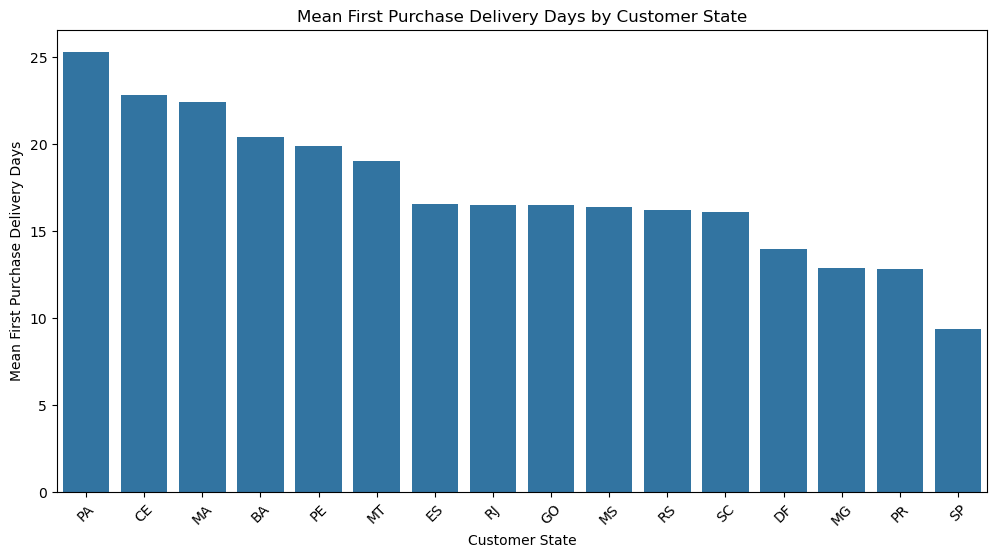

In [45]:
plt.figure(figsize=(12, 6))

plot_df = state_logistics_experience_main.sort_values(
    "first_purchase_delivery_days_mean",
    ascending=False
)

sns.barplot(
    data=plot_df,
    x="customer_state",
    y="first_purchase_delivery_days_mean"
)

plt.title("Mean First Purchase Delivery Days by Customer State")
plt.xlabel("Customer State")
plt.ylabel("Mean First Purchase Delivery Days")
plt.xticks(rotation=45)
plt.show()

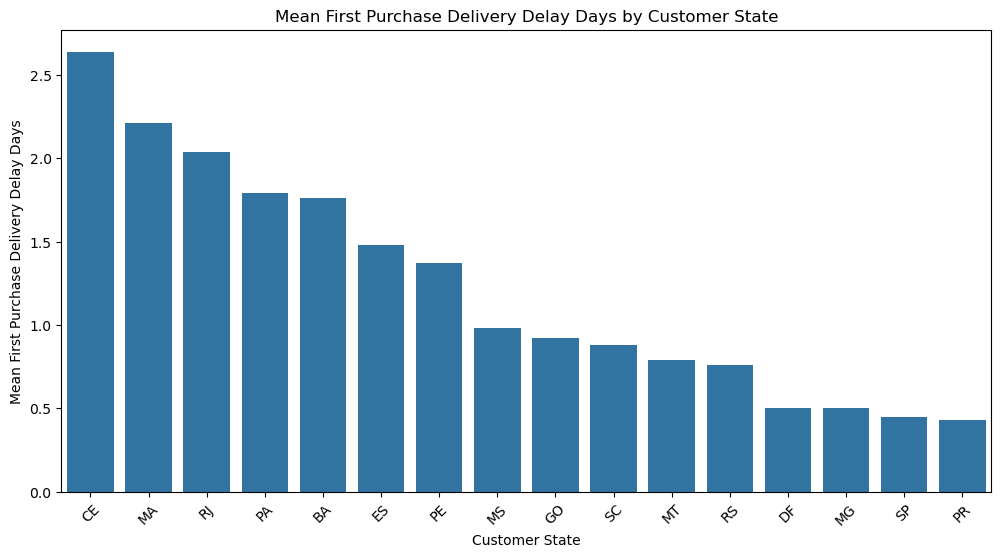

In [46]:
plt.figure(figsize=(12, 6))

plot_df = state_logistics_experience_main.sort_values(
    "first_purchase_delivery_delay_days_mean",
    ascending=False
)

sns.barplot(
    data=plot_df,
    x="customer_state",
    y="first_purchase_delivery_delay_days_mean"
)

plt.title("Mean First Purchase Delivery Delay Days by Customer State")
plt.xlabel("Customer State")
plt.ylabel("Mean First Purchase Delivery Delay Days")
plt.xticks(rotation=45)
plt.show()

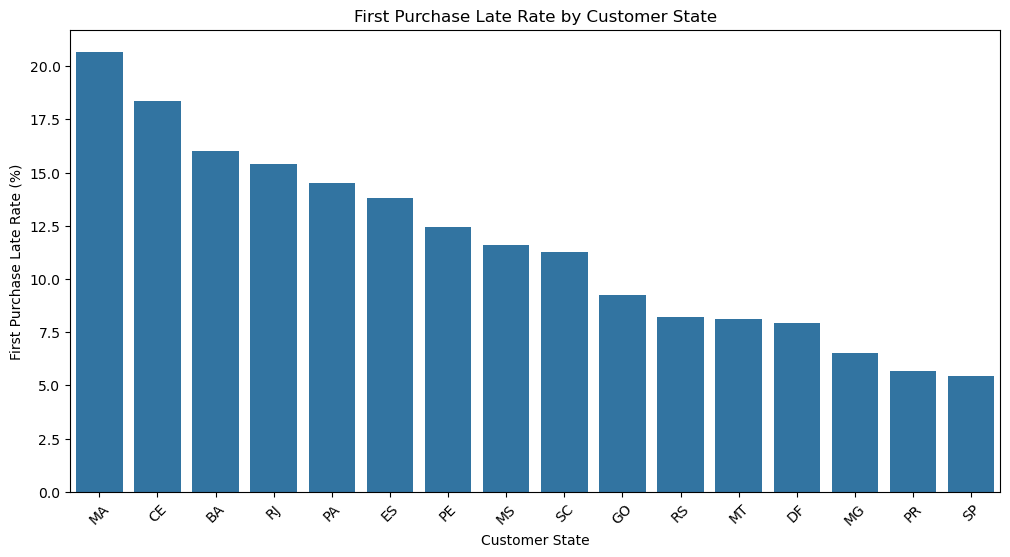

In [47]:
plt.figure(figsize=(12, 6))

plot_df = state_logistics_experience_main.sort_values(
    "first_purchase_late_rate",
    ascending=False
)

sns.barplot(
    data=plot_df,
    x="customer_state",
    y="first_purchase_late_rate"
)

plt.title("First Purchase Late Rate by Customer State")
plt.xlabel("Customer State")
plt.ylabel("First Purchase Late Rate (%)")
plt.xticks(rotation=45)
plt.show()

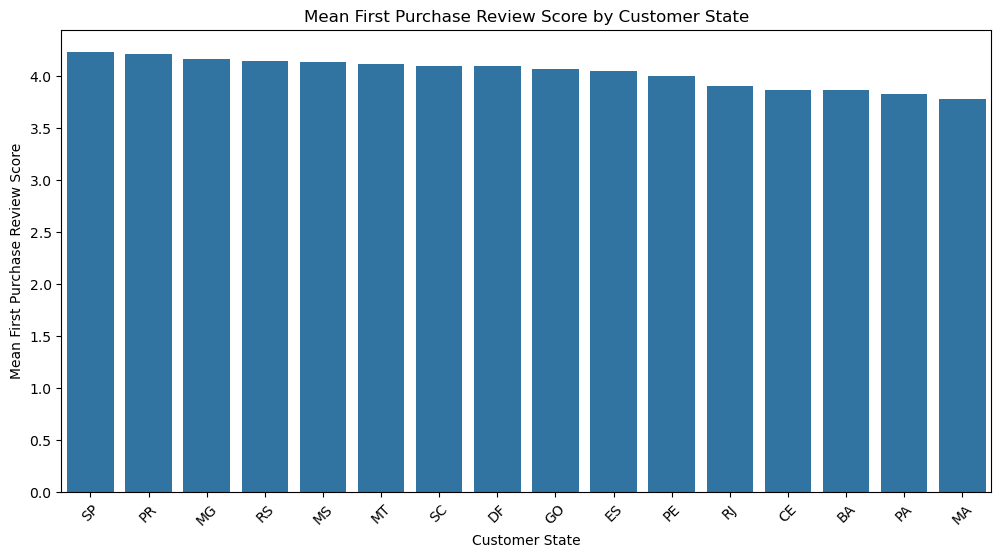

In [48]:
plt.figure(figsize=(12, 6))

plot_df = state_logistics_experience_main.sort_values(
    "first_purchase_review_score_mean",
    ascending=False
)

sns.barplot(
    data=plot_df,
    x="customer_state",
    y="first_purchase_review_score_mean"
)

plt.title("Mean First Purchase Review Score by Customer State")
plt.xlabel("Customer State")
plt.ylabel("Mean First Purchase Review Score")
plt.xticks(rotation=45)
plt.show()

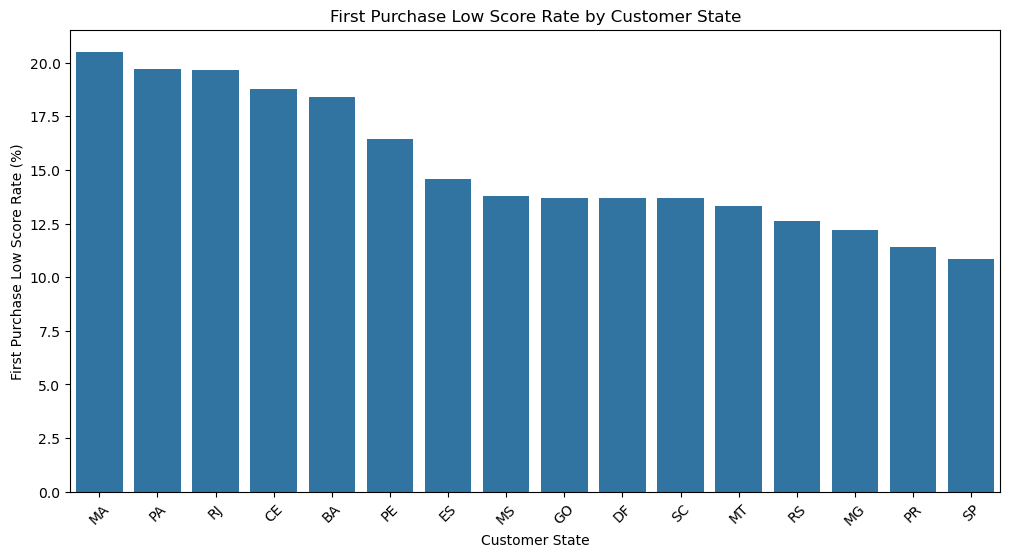

In [49]:
plt.figure(figsize=(12, 6))

plot_df = state_logistics_experience_main.sort_values(
    "first_purchase_low_score_rate",
    ascending=False
)

sns.barplot(
    data=plot_df,
    x="customer_state",
    y="first_purchase_low_score_rate"
)

plt.title("First Purchase Low Score Rate by Customer State")
plt.xlabel("Customer State")
plt.ylabel("First Purchase Low Score Rate (%)")
plt.xticks(rotation=45)
plt.show()

In [50]:
state_logistics_experience_main.sort_values(
    [
        "first_purchase_delivery_days_mean",
        "first_purchase_late_rate",
        "first_purchase_low_score_rate"
    ],
    ascending=False
)

,customer_state,customer_count,repurchase_2nd_within_90d_count,first_purchase_delivery_days_mean,first_purchase_delivery_days_median,first_purchase_delivery_delay_days_mean,first_purchase_delivery_delay_days_median,first_purchase_late_rate,first_purchase_review_score_mean,first_purchase_low_score_rate,repurchase_2nd_within_90d_rate
0,PA,771,6,25.31,22.57,1.79,0.0,14.53,3.82,19.71,0.78
1,CE,1050,11,22.83,19.73,2.64,0.0,18.38,3.86,18.76,1.05
2,MA,590,3,22.39,19.73,2.21,0.0,20.68,3.78,20.51,0.51
3,BA,2573,39,20.42,18.09,1.76,0.0,16.01,3.86,18.38,1.52
4,PE,1247,14,19.90,17.28,1.37,0.0,12.43,4.00,16.44,1.12
5,MT,714,14,19.03,17.19,0.79,0.0,8.12,4.11,13.31,1.96
6,ES,1587,35,16.56,14.24,1.48,0.0,13.80,4.04,14.56,2.21
7,RJ,9864,149,16.52,13.10,2.04,0.0,15.41,3.90,19.64,1.51
8,GO,1576,24,16.47,14.68,0.92,0.0,9.26,4.06,13.71,1.52
9,MS,551,7,16.37,14.37,0.98,0.0,11.62,4.13,13.79,1.27


In [51]:
# 2.2 地區差異是否主要來自物流
# 州別90天二購率是否和物流指標同步變動

| 檢查             | 如果成立  | 代表                                    |
| -------------- | ----- | ------------------------------------- |
| 高二購州配送較快、延遲率較低 | 有同步關係 | 物流可能是原因之一                             |
| 控制物流後，州別效果大幅下降 | 成立    | 地區差異主要來自物流                            |
| 控制物流後，州別差異仍存在  | 成立    | 地區差異不只來自物流，可能還有市場成熟度、品類、消費習慣、競爭、價格等因素 |


In [57]:
# =========================
# 5.2 地區差異是否主要來自物流？
# =========================

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score, log_loss
from sklearn.impute import SimpleImputer

df = state_logistics_experience_base.copy()

# 1. 保留分析需要欄位
cols = [
    "customer_unique_id",
    "customer_state",
    "first_purchase_delivery_days",
    "first_purchase_delivery_delay_days",
    "first_purchase_late_flag",
    "first_purchase_review_score_mean",
    "first_purchase_low_score_flag",
    "repurchase_2nd_within_90d_flag"
]

df = df[cols].copy()

# 2. 移除 target 缺失
df = df.dropna(subset=["repurchase_2nd_within_90d_flag", "customer_state"]).copy()

# 3. target 轉 int
df["repurchase_2nd_within_90d_flag"] = df["repurchase_2nd_within_90d_flag"].astype(int)

print("分析筆數:", len(df))
print("90天二購率:", df["repurchase_2nd_within_90d_flag"].mean())

分析筆數: 75320
90天二購率: 0.014763674986723313


In [53]:
# =========================
# A. 州別彙總表
# =========================

state_summary = (
    df.groupby("customer_state")
    .agg(
        customer_count=("customer_unique_id", "nunique"),
        repurchase_2nd_within_90d_count=("repurchase_2nd_within_90d_flag", "sum"),
        repurchase_2nd_within_90d_rate=("repurchase_2nd_within_90d_flag", "mean"),
        delivery_days_mean=("first_purchase_delivery_days", "mean"),
        delivery_days_median=("first_purchase_delivery_days", "median"),
        delivery_delay_days_mean=("first_purchase_delivery_delay_days", "mean"),
        delivery_delay_days_median=("first_purchase_delivery_delay_days", "median"),
        late_rate=("first_purchase_late_flag", "mean"),
        review_score_mean=("first_purchase_review_score_mean", "mean"),
        low_score_rate=("first_purchase_low_score_flag", "mean")
    )
    .reset_index()
)

# 百分比轉換
rate_cols = [
    "repurchase_2nd_within_90d_rate",
    "late_rate",
    "low_score_rate"
]

for col in rate_cols:
    state_summary[col + "_pct"] = state_summary[col] * 100

# 建議只看樣本數足夠的州，避免小樣本誤判
min_customer_count = 500

state_summary_filtered = state_summary[
    state_summary["customer_count"] >= min_customer_count
].copy()

state_summary_filtered = state_summary_filtered.sort_values(
    "repurchase_2nd_within_90d_rate",
    ascending=False
)

display(state_summary_filtered)

,customer_state,customer_count,repurchase_2nd_within_90d_count,repurchase_2nd_within_90d_rate,delivery_days_mean,delivery_days_median,delivery_delay_days_mean,delivery_delay_days_median,late_rate,review_score_mean,low_score_rate,repurchase_2nd_within_90d_rate_pct,late_rate_pct,low_score_rate_pct
7,ES,1587,35,0.022054,16.563610,14.235417,1.481904,0.0,0.137996,4.035760,0.145558,2.205419,13.799622,14.555766
12,MT,714,14,0.019608,19.031296,17.189583,0.787559,0.0,0.081232,4.108956,0.133053,1.960784,8.123249,13.305322
25,SP,30791,496,0.016109,9.382832,7.854861,0.451148,0.0,0.054594,4.226359,0.108701,1.610860,5.459387,10.870059
8,GO,1576,24,0.015228,16.466011,14.683333,0.922179,0.0,0.092640,4.064696,0.137056,1.522843,9.263959,13.705584
4,BA,2573,39,0.015157,20.424987,18.086111,1.759142,0.0,0.160124,3.864412,0.183832,1.515740,16.012437,18.383210
18,RJ,9864,149,0.015105,16.515913,13.104514,2.044510,0.0,0.154096,3.898808,0.196371,1.510543,15.409570,19.637064
10,MG,9004,127,0.014105,12.865421,11.248611,0.495060,0.0,0.065415,4.157103,0.122057,1.410484,6.541537,12.205686
22,RS,4289,60,0.013989,16.230753,14.130208,0.762850,0.0,0.082070,4.142022,0.126137,1.398927,8.207041,12.613663
6,DF,1576,21,0.013325,13.947441,12.354167,0.497895,0.0,0.079315,4.090779,0.137056,1.332487,7.931472,13.705584
11,MS,551,7,0.012704,16.371393,14.367361,0.984021,0.0,0.116152,4.127727,0.137931,1.270417,11.615245,13.793103


In [54]:
# =========================
# B. 州別二購率與物流 / 體驗指標相關性
# =========================

corr_cols = [
    "repurchase_2nd_within_90d_rate",
    "delivery_days_mean",
    "delivery_delay_days_mean",
    "late_rate",
    "review_score_mean",
    "low_score_rate"
]

corr_result = state_summary_filtered[corr_cols].corr()

display(corr_result)

# 只取與二購率的相關
repurchase_corr = (
    corr_result["repurchase_2nd_within_90d_rate"]
    .drop("repurchase_2nd_within_90d_rate")
    .sort_values()
)

display(repurchase_corr)

,repurchase_2nd_within_90d_rate,delivery_days_mean,delivery_delay_days_mean,late_rate,review_score_mean,low_score_rate
repurchase_2nd_within_90d_rate,1.000000,-0.462474,-0.358256,-0.427213,0.475775,-0.483355
delivery_days_mean,-0.462474,1.000000,0.794729,0.795997,-0.865802,0.832881
delivery_delay_days_mean,-0.358256,0.794729,1.000000,0.957181,-0.919888,0.928293
late_rate,-0.427213,0.795997,0.957181,1.000000,-0.929312,0.927319
review_score_mean,0.475775,-0.865802,-0.919888,-0.929312,1.000000,-0.984975
low_score_rate,-0.483355,0.832881,0.928293,0.927319,-0.984975,1.000000


low_score_rate             -0.483355
delivery_days_mean         -0.462474
late_rate                  -0.427213
delivery_delay_days_mean   -0.358256
review_score_mean           0.475775
Name: repurchase_2nd_within_90d_rate, dtype: float64

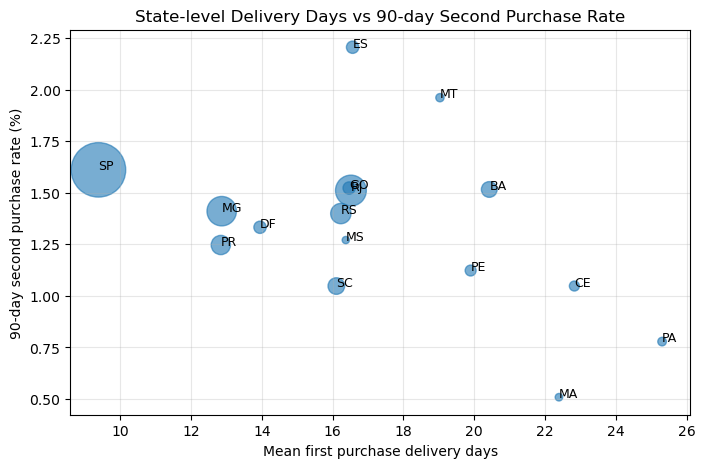

In [55]:
# =========================
# C1. 平均配送天數 vs 二購率
# =========================

plot_df = state_summary_filtered.copy()

plt.figure(figsize=(8, 5))
plt.scatter(
    plot_df["delivery_days_mean"],
    plot_df["repurchase_2nd_within_90d_rate_pct"],
    s=plot_df["customer_count"] / 20,
    alpha=0.6
)

for _, row in plot_df.iterrows():
    plt.text(
        row["delivery_days_mean"],
        row["repurchase_2nd_within_90d_rate_pct"],
        row["customer_state"],
        fontsize=9
    )

plt.xlabel("Mean first purchase delivery days")
plt.ylabel("90-day second purchase rate (%)")
plt.title("State-level Delivery Days vs 90-day Second Purchase Rate")
plt.grid(alpha=0.3)
plt.show()

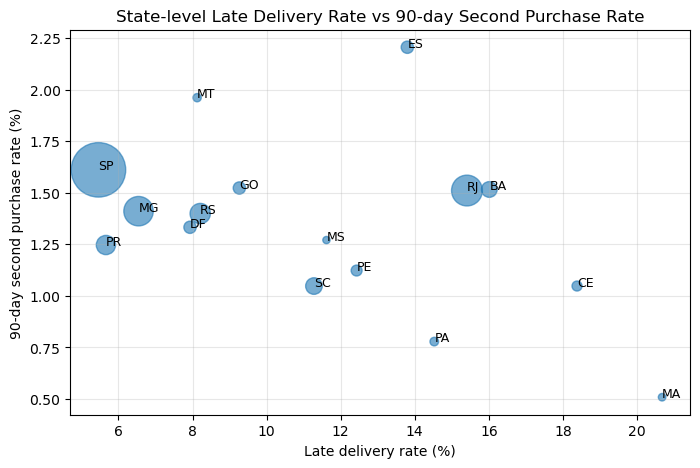

In [56]:
# =========================
# C2. 延遲率 vs 二購率
# =========================

plt.figure(figsize=(8, 5))
plt.scatter(
    plot_df["late_rate_pct"],
    plot_df["repurchase_2nd_within_90d_rate_pct"],
    s=plot_df["customer_count"] / 20,
    alpha=0.6
)

for _, row in plot_df.iterrows():
    plt.text(
        row["late_rate_pct"],
        row["repurchase_2nd_within_90d_rate_pct"],
        row["customer_state"],
        fontsize=9
    )

plt.xlabel("Late delivery rate (%)")
plt.ylabel("90-day second purchase rate (%)")
plt.title("State-level Late Delivery Rate vs 90-day Second Purchase Rate")
plt.grid(alpha=0.3)
plt.show()